
---

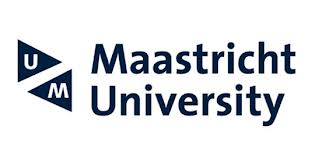

# Faculty of Science and Engineering - Department of Advanced Computer Sciences
# Course Advanced Natural Language Processing - Tutorial Tokenization

⏱️ **Estimated time:** 1.6 hours – 3.5 hours


By Jan Scholtes


---

Version 2026-2027

---

Welcome to the tutorial on Dialogue and ChatBots. In this notebook we explore the evolution of conversational AI, from the earliest pattern-matching systems (ELIZA, 1966) through retrieval-based models to modern LLM-powered chatbots.

We will examine different chatbot architectures: rule-based (ELIZA, ALICE), retrieval-based (ChatterBot), model-based (TF-IDF/cosine similarity), and generative (LLM-based). We also discuss how to evaluate chatbot quality and the role of Natural Language Understanding (NLU), Natural Language Generation (NLG), and Dialog Management (DM).

For this notebook we would need our GPU accelerator. Make sure you have selected the GPU runtime in Google Colab (Runtime > Change Runtime Type > T4 GPU).

## Learning Goals

After completing this tutorial, you will be able to:

- **Understand** the historical evolution of chatbots from ELIZA to modern LLMs.
- **Implement** pattern-based chatbots using regular expressions and NLTK's `Chat` class.
- **Explain** how ALICE uses AIML and how ChatterBot uses retrieval-based methods.
- **Build** a retrieval-based chatbot using TF-IDF and cosine similarity over a knowledge base.
- **Identify** the NLU, NLG, and DM components in a model-based chatbot architecture.
- **Compare** template/retrieval-driven chatbots with generative AI (LLM) chatbots.
- **Evaluate** chatbot quality using both automated metrics and human evaluation criteria.
- **Use** transformer-based models for conversational AI applications.


A **chatbot** or **chatterbot** is a software application used to conduct an on-line chat conversation via text or text-to-speech, in lieu of providing direct contact with a live human agent. Designed to convincingly simulate the way a human would behave as a conversational partner, chatbot systems typically require continuous tuning and testing, and many in production remain unable to adequately converse, while none of them can pass the standard Turing test. The term "ChatterBot" was originally coined by Michael Mauldin (creator of the first Verbot) in 1994 to describe these conversational programs.

Chatbots are used in dialog systems for various purposes including customer service, request routing, or information gathering. While some chatbot applications use extensive word-classification processes, natural-language processors, and sophisticated AI, others simply scan for general keywords and generate responses using common phrases obtained from an associated library or database.

Most chatbots are accessed on-line via website popups or through virtual assistants. They can be classified into usage categories that include: commerce (e-commerce via chat), education, entertainment, finance, health, news, and productivity.

# ELIZA and PARRY

Among the most notable early chatbots are ELIZA (1966) and PARRY (1972). Joseph Weizenbaum's program ELIZA, published in 1966, which seemed to be able to fool users into believing that they were conversing with a real human. However Weizenbaum himself did not claim that ELIZA was genuinely intelligent. PARRY was the first model to pass (for some users) the Turing test, but that could also have to do with the fact that it was designed to simulate a paranoide patient, allowing it to avoid in-depth topical discussions.

While ELIZA and PARRY were used exclusively to simulate typed conversation, many chatbots now include other functional features, such as games and web searching abilities.

ELIZA is part of the NTLK code (source code can be found here: https://www.nltk.org/_modules/nltk/chat/eliza.html). As you can see, it is a really simple program. So, let's try that first... (use 'quit' to end your therapy session)

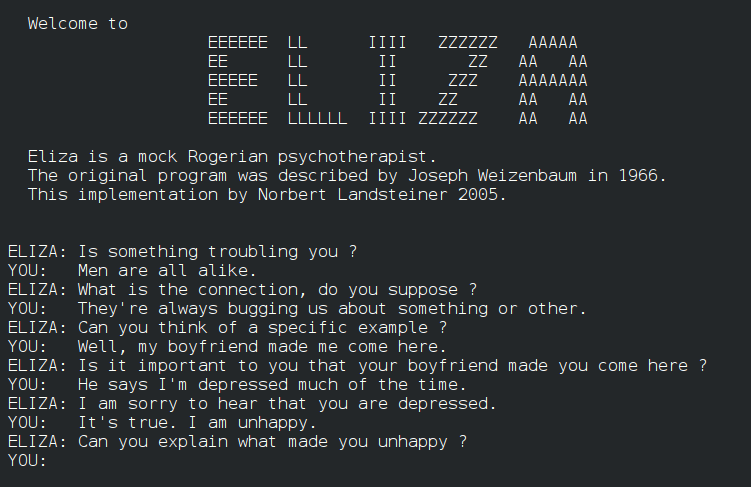


In [ ]:


# Natural Language Toolkit: Eliza
#
# Copyright (C) 2001-2022 NLTK Project
# Authors: Steven Bird <stevenbird1@gmail.com>
#          Edward Loper <edloper@gmail.com>
# URL: <https://www.nltk.org/>
# For license information, see LICENSE.TXT

# Based on an Eliza implementation by Joe Strout <joe@strout.net>,
# Jeff Epler <jepler@inetnebr.com> and Jez Higgins <mailto:jez@jezuk.co.uk>.

# a translation table used to convert things you say into things the
# computer says back, e.g. "I am" --> "you are"

import nltk
from nltk.chat.util import Chat, reflections

pairs = (
    (
        r"I need (.*)",
        (
            "Why do you need %1?",
            "Would it really help you to get %1?",
            "Are you sure you need %1?",
        ),
    ),
    (
        r"Why don\'t you (.*)",
        (
            "Do you really think I don't %1?",
            "Perhaps eventually I will %1.",
            "Do you really want me to %1?",
        ),
    ),
    (
        r"Why can\'t I (.*)",
        (
            "Do you think you should be able to %1?",
            "If you could %1, what would you do?",
            "I don't know -- why can't you %1?",
            "Have you really tried?",
        ),
    ),
    (
        r"I can\'t (.*)",
        (
            "How do you know you can't %1?",
            "Perhaps you could %1 if you tried.",
            "What would it take for you to %1?",
        ),
    ),
    (
        r"I am (.*)",
        (
            "Did you come to me because you are %1?",
            "How long have you been %1?",
            "How do you feel about being %1?",
        ),
    ),
    (
        r"I\'m (.*)",
        (
            "How does being %1 make you feel?",
            "Do you enjoy being %1?",
            "Why do you tell me you're %1?",
            "Why do you think you're %1?",
        ),
    ),
    (
        r"Are you (.*)",
        (
            "Why does it matter whether I am %1?",
            "Would you prefer it if I were not %1?",
            "Perhaps you believe I am %1.",
            "I may be %1 -- what do you think?",
        ),
    ),
    (
        r"What (.*)",
        (
            "Why do you ask?",
            "How would an answer to that help you?",
            "What do you think?",
        ),
    ),
    (
        r"How (.*)",
        (
            "How do you suppose?",
            "Perhaps you can answer your own question.",
            "What is it you're really asking?",
        ),
    ),
    (
        r"Because (.*)",
        (
            "Is that the real reason?",
            "What other reasons come to mind?",
            "Does that reason apply to anything else?",
            "If %1, what else must be true?",
        ),
    ),
    (
        r"(.*) sorry (.*)",
        (
            "There are many times when no apology is needed.",
            "What feelings do you have when you apologize?",
        ),
    ),
    (
        r"Hello(.*)",
        (
            "Hello... I'm glad you could drop by today.",
            "Hi there... how are you today?",
            "Hello, how are you feeling today?",
        ),
    ),
    (
        r"I think (.*)",
        ("Do you doubt %1?", "Do you really think so?", "But you're not sure %1?"),
    ),
    (
        r"(.*) friend (.*)",
        (
            "Tell me more about your friends.",
            "When you think of a friend, what comes to mind?",
            "Why don't you tell me about a childhood friend?",
        ),
    ),
    (r"Yes", ("You seem quite sure.", "OK, but can you elaborate a bit?")),
    (
        r"(.*) computer(.*)",
        (
            "Are you really talking about me?",
            "Does it seem strange to talk to a computer?",
            "How do computers make you feel?",
            "Do you feel threatened by computers?",
        ),
    ),
    (
        r"Is it (.*)",
        (
            "Do you think it is %1?",
            "Perhaps it's %1 -- what do you think?",
            "If it were %1, what would you do?",
            "It could well be that %1.",
        ),
    ),
    (
        r"It is (.*)",
        (
            "You seem very certain.",
            "If I told you that it probably isn't %1, what would you feel?",
        ),
    ),
    (
        r"Can you (.*)",
        (
            "What makes you think I can't %1?",
            "If I could %1, then what?",
            "Why do you ask if I can %1?",
        ),
    ),
    (
        r"Can I (.*)",
        (
            "Perhaps you don't want to %1.",
            "Do you want to be able to %1?",
            "If you could %1, would you?",
        ),
    ),
    (
        r"You are (.*)",
        (
            "Why do you think I am %1?",
            "Does it please you to think that I'm %1?",
            "Perhaps you would like me to be %1.",
            "Perhaps you're really talking about yourself?",
        ),
    ),
    (
        r"You\'re (.*)",
        (
            "Why do you say I am %1?",
            "Why do you think I am %1?",
            "Are we talking about you, or me?",
        ),
    ),
    (
        r"I don\'t (.*)",
        ("Don't you really %1?", "Why don't you %1?", "Do you want to %1?"),
    ),
    (
        r"I feel (.*)",
        (
            "Good, tell me more about these feelings.",
            "Do you often feel %1?",
            "When do you usually feel %1?",
            "When you feel %1, what do you do?",
        ),
    ),
    (
        r"I have (.*)",
        (
            "Why do you tell me that you've %1?",
            "Have you really %1?",
            "Now that you have %1, what will you do next?",
        ),
    ),
    (
        r"I would (.*)",
        (
            "Could you explain why you would %1?",
            "Why would you %1?",
            "Who else knows that you would %1?",
        ),
    ),
    (
        r"Is there (.*)",
        (
            "Do you think there is %1?",
            "It's likely that there is %1.",
            "Would you like there to be %1?",
        ),
    ),
    (
        r"My (.*)",
        (
            "I see, your %1.",
            "Why do you say that your %1?",
            "When your %1, how do you feel?",
        ),
    ),
    (
        r"You (.*)",
        (
            "We should be discussing you, not me.",
            "Why do you say that about me?",
            "Why do you care whether I %1?",
        ),
    ),
    (r"Why (.*)", ("Why don't you tell me the reason why %1?", "Why do you think %1?")),
    (
        r"I want (.*)",
        (
            "What would it mean to you if you got %1?",
            "Why do you want %1?",
            "What would you do if you got %1?",
            "If you got %1, then what would you do?",
        ),
    ),
    (
        r"(.*) mother(.*)",
        (
            "Tell me more about your mother.",
            "What was your relationship with your mother like?",
            "How do you feel about your mother?",
            "How does this relate to your feelings today?",
            "Good family relations are important.",
        ),
    ),
    (
        r"(.*) father(.*)",
        (
            "Tell me more about your father.",
            "How did your father make you feel?",
            "How do you feel about your father?",
            "Does your relationship with your father relate to your feelings today?",
            "Do you have trouble showing affection with your family?",
        ),
    ),
    (
        r"(.*) child(.*)",
        (
            "Did you have close friends as a child?",
            "What is your favorite childhood memory?",
            "Do you remember any dreams or nightmares from childhood?",
            "Did the other children sometimes tease you?",
            "How do you think your childhood experiences relate to your feelings today?",
        ),
    ),
    (
        r"(.*)\?",
        (
            "Why do you ask that?",
            "Please consider whether you can answer your own question.",
            "Perhaps the answer lies within yourself?",
            "Why don't you tell me?",
        ),
    ),
    (
        r"quit",
        (
            "Thank you for talking with me.",
            "Good-bye.",
            "Thank you, that will be $150.  Have a good day!",
        ),
    ),
    (
        r"(.*)",
        (
            "Please tell me more.",
            "Let's change focus a bit... Tell me about your family.",
            "Can you elaborate on that?",
            "Why do you say that %1?",
            "I see.",
            "Very interesting.",
            "%1.",
            "I see.  And what does that tell you?",
            "How does that make you feel?",
            "How do you feel when you say that?",
        ),
    ),
)

eliza_chatbot = Chat(pairs, reflections)


def eliza_chat():
    print("Therapist\n---------")
    print("Talk to the program by typing in plain English, using normal upper-")
    print('and lower-case letters and punctuation.  Enter "quit" when done.')
    print("=" * 72)
    print("Hello.  How are you feeling today?")

    eliza_chatbot.converse()



def demo():
    eliza_chat()



if __name__ == "__main__":
    demo()


Based on the principle of ELIZA, there are a few alternative chat bots available in NLTK (all based on a few simple pattern matching rules):

    (eliza_chat, "Eliza (psycho-babble)"),
    (iesha_chat, "Iesha (teen anime junky)"),
    (rude_chat, "Rude (abusive bot)"),
    (suntsu_chat, "Suntsu (Chinese sayings)"),
    (zen_chat, "Zen (gems of wisdom)"),

    See also: https://www.nltk.org/_modules/nltk/chat.html

Now that you got the trick, you can probably write a simple chatbot using pattern matching rules and keep the conversation going for hours. But we will leave that for now, and move on to more interesting chatbots.

# A.L.I.C.E. and Jabberwacky

Other notable chatbot programs include A.L.I.C.E., Jabberwacky and D.U.D.E (Agence Nationale de la Recherche and CNRS 2006).

A.L.I.C.E. uses a markup language called AIML, which is specific to its function as a conversational agent, and has since been adopted by various other developers of, so-called, Alicebots. Nevertheless, A.L.I.C.E. is still purely based on pattern matching techniques without any reasoning capabilities, the same technique ELIZA was using back in 1966. This is not strong AI, which would require sapience and logical reasoning abilities.

Jabberwacky learns new responses and context based on real-time user interactions, rather than being driven from a static database.


The ALICE bot’s response the observation, and wraps it into an action’s reply. The ALICE bot is a strong rule-based bot uing AIML (https://en.wikipedia.org/wiki/Artificial_Intelligence_Markup_Language).

Here you can find a working demo of ALICE: https://www.pandorabots.com/pandora/talk?botid=b8d616e35e36e881

The source code can be found here: https://github.com/paulovn/python-aiml

AIML filea are XML-based script files. For ALICE, several of such script files are available, you can find them here: https://github.com/paulovn/python-aiml/tree/master/aiml/botdata/alice  

Scripts are available to discuss topics such as astrology, food, computers, drugs, emotions, etc. Try some of those. Also try to get off script!

# Chatterbot

Chatterbot is entirely based on information retrieval and Naive Bayes machine learning. it is language indepdendent as it has no NLU or NLP module. the conversations are based on "sentence picking" from a dialogue corpus containing question-answers.  

Chaterbot has corpera on various language - topics: https://github.com/gunthercox/chatterbot-corpus/tree/master/chatterbot_corpus/data


An untrained instance of ChatterBot starts off with no knowledge of how to communicate. Each time a user enters a statement, the library saves the text that they entered and the text that the statement was in response to. As ChatterBot receives more input the number of responses that it can reply and the accuracy of each response in relation to the input statement increase. The program selects the closest matching response by searching for the closest matching known statement that matches the input, it then returns the most likely response to that statement based on how frequently each response is issued by the people the bot communicates with.


See also: https://chatterbot.readthedocs.io/en/stable/faq.html

Here you can get an idea of the structure of the conversations (*.YML files) and how to add more sentence-pairs to the model: https://github.com/gunthercox/chatterbot-corpus/blob/master/chatterbot_corpus/data/english/conversations.yml

I am curious of you can get a normal conversation with this bot?

In [ ]:
import importlib, subprocess, sys, os
if importlib.util.find_spec('chatterpy') is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                           "git+https://github.com/ShoneGK/ChatterPy"])
if not os.path.exists('chatterbot-corpus'):
    subprocess.check_call(["git", "clone", "https://github.com/gunthercox/chatterbot-corpus"])
    !mv /content/chatterbot-corpus/chatterbot_corpus /root/


In [ ]:
import os

import spacy
from spacy.cli.download import download
download(model="en_core_web_sm")

from chatterbot import languages
languages.ENG.ISO_639_1 = "en_core_web_sm"

# import chatterbot
from chatterbot import ChatBot
from chatterbot.trainers import ListTrainer
from chatterbot.trainers import ChatterBotCorpusTrainer

bot = ChatBot("Lohith")
# trainer = ListTrainer(bot)

trainer = ChatterBotCorpusTrainer(bot)

trainer.train(
    "chatterbot.corpus.english"
)

# Train the chatbot based on the english corpus
trainer.train("chatterbot.corpus.english")

while True:
    message = input("You: ")
    if message.strip().lower() != "bye" or message.strip().lower() =="tata":
        reply = bot.get_response(message)
        print("Lohith: ",reply)
    elif message.strip().lower() =="bye" or message.strip().lower() =="tata":
        print("okay")
        break


# More Recent Chatbots

More recent chatbots combine real-time learning with machine learning algorithms that optimize their ability to communicate based on each conversation held.

Modern chatbots differentiate themselves from the earlier discussed pattern-matching and rules-based models: they have seperate Natural Language Understanding (NLU), Natural Language Generation (NLG), and a Dialog Manager (DM) consisting of a Dialog State Tracking and Dialog Policy. They can use external knowledge-bases (often querying of Wikipedia or a dedicated knowledge-base containing RDF tupples: https://en.wikipedia.org/wiki/Resource_Description_Framework  ).

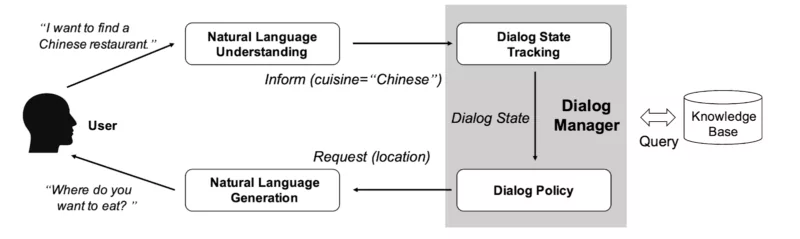

The NLU, NLP and Dialog Manager can be either rules-based (grammars), statistical, use deep learning, or a hybrid combination of all of the above.   

A very basic example of a model based on NLTK using rudimentory NLU, NLG and DM can be found hereunder. Try to have a decent conversation on global warming with this Chatbot (the relevant sentence-pairs for the conversation on global warming comes from the wikipedia page: https://en.wikipedia.org/wiki/Global_warming which you can use to get inspiration for your dialogue).

In [ ]:
import bs4 as bs
import urllib.request
import re
import requests

import nltk
import numpy as np
import random
import string

import nltk
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

import warnings
warnings.filterwarnings('ignore')
import os
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
import transformers
transformers.logging.set_verbosity_error()
from datasets import disable_progress_bar
disable_progress_bar()

# raw_data = urllib.request.urlopen('https://en.wikipedia.org/wiki/Climate_change')
# raw_data = raw_data.read()

url = 'https://en.wikipedia.org/wiki/Climate_change'
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'}
response = requests.get(url, headers=headers)
raw_data = response.text


html_data = bs.BeautifulSoup(raw_data,'lxml')

all_paragraphs =html_data.find_all('p')

article_content = ""

for p in all_paragraphs:
    article_content += p.text

article_content =  article_content.lower()# converts to lowercase

article_content  = re.sub(r'\[[0-9]*\]', ' ', article_content )
article_content = re.sub(r'\s+', ' ', article_content )

sentence_list = nltk.sent_tokenize(article_content)
article_words= nltk.word_tokenize(article_content )

lemmatizer = nltk.stem.WordNetLemmatizer()

def LemmatizeWords(words):
    return [lemmatizer.lemmatize(word) for word in words]

remove_punctuation= dict((ord(punctuation), None) for punctuation in string.punctuation)

def RemovePunctuations(text):
    return LemmatizeWords(nltk.word_tokenize(text.lower().translate(remove_punctuation)))

greeting_input_texts = ("hey", "heys", "hello", "morning", "evening","greetings",)
greeting_replie_texts = ["hey", "hey hows you?", "*nods*", "hello there", "ello", "Welcome, how are you"]

def reply_greeting(text):

    for word in text.split():
        if word.lower() in greeting_input_texts:
            return random.choice(greeting_replie_texts)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


def give_reply(user_input):
    chatbot_response=''
    sentence_list.append(user_input)
    word_vectors = TfidfVectorizer(tokenizer=RemovePunctuations, stop_words='english')
    vecrorized_words = word_vectors.fit_transform(sentence_list)
    similarity_values = cosine_similarity(vecrorized_words[-1], vecrorized_words)
    similar_sentence_number =similarity_values.argsort()[0][-2]
    similar_vectors = similarity_values.flatten()
    similar_vectors.sort()
    matched_vector = similar_vectors[-2]
    if(matched_vector ==0):
        chatbot_response=chatbot_response+"I am sorry! I don't understand you"
        return chatbot_response
    else:
        chatbot_response = chatbot_response +sentence_list[similar_sentence_number]
        return chatbot_response

**Try the chatbot below** by running the next cell. Type your questions about global warming and type 'bye' to end the conversation. You can also type 'thanks' to exit.

In [ ]:
continue_discussion=True
print("Hello, I am a chatbot, I will answer your queries regarding global warming:")
while(continue_discussion==True):
    user_input = input()
    user_input = user_input .lower()
    if(user_input !='bye'):
        if(user_input =='thanks' or user_input =='thank you very much'  or user_input =='thank you'):
            continue_discussion=False
            print("Chatbot: Most welcome")
        else:
            if(reply_greeting(user_input)!=None):
                print("Chatbot: "+reply_greeting(user_input))
            else:
                print("Chatbot: ",end="")
                print(give_reply(user_input))
                sentence_list.remove(user_input)
    else:
        continue_discussion=False
        print("Chatbot: Take care, bye ..")

The above model uses tokenization, lemmatization, basic greeting, information retrieval, sentence picking and a wikipedia-based knowledge base. All pretty basic.

| Aspect                 | Template / retrieval chatbots | Generative AI (ChatGPT / Bard / etc.) |
| ---------------------- | ----------------------------- | ------------------------------------- |
| Response type          | Predefined or copied          | **Generated and unique**              |
| Language understanding | Keyword / pattern matching    | **Semantic and context-aware**        |
| Flexibility            | Very limited                  | **High — can answer follow-ups**      |
| Personalization        | None                          | **Adapts to tone, level, format**     |
| Depth of explanation   | Low                           | **High (can reason and explain)**     |


#Large Language Models for Chatbots

Large Language Models (LLMs) are particularly well-suited for chatbots for several reasons:

1. Natural Language Understanding (NLU)
Contextual Understanding: LLMs, such as GPT-based models, have been trained on vast amounts of diverse text data. This training allows them to understand context, intent, and nuances in conversation better than traditional rule-based systems or smaller models.
Handling Ambiguity: They can handle ambiguous or vague queries and still provide relevant responses, thanks to their training in recognizing varied language patterns.
2. Versatility and Flexibility
Wide Range of Topics: LLMs can discuss a broad spectrum of topics, making them useful for general-purpose chatbots capable of engaging in small talk, answering questions, providing recommendations, and more.
Dynamic Interactions: Unlike simpler systems, LLMs can adapt their responses based on previous inputs, maintaining coherent and contextually relevant conversations.
3. Human-Like Responses
Natural Output: The responses generated by LLMs often feel more conversational and human-like, contributing to an enhanced user experience.
Customization: Developers can fine-tune these models for specific tasks, enabling chatbots to adopt particular tones, personalities, or styles that match business or user needs.
4. Learning from Large Datasets
Pre-Trained Knowledge: LLMs are trained on massive datasets that encompass a variety of domains, which allows them to answer questions and provide information without needing extensive training or updates.
Transfer Learning: They can be fine-tuned with smaller, domain-specific datasets to further refine their responses for specialized applications (e.g., medical advice, customer service).
5. Reduced Development Time
Pre-Built Capabilities: Because LLMs already have a vast amount of general knowledge, developers don't need to create chatbot responses from scratch. This reduces the development time and complexity.
Plug-and-Play: Many modern LLM-based chatbots can be integrated with existing platforms with minimal customization.

LLMs are particulary designed to provide a conversational interface to other data sources. As we have seen, they are really good at this!

But, as we have seen, LLM's ar enot really good in sticking to the facts. For this, we need to add additional functionality such as fact-chacking, advanced (background or system) prompt engineering, Retrieval Augmented Generation (by either search or driven from a Knowledge Graph).

In the lecture on Agents we will take a closer look at chatbots implementing more complex tasks. In the course on Information Retrieval and Text Mining, we will discuss Retrieval Augmented Generation in much more detail and how they can help us to keep chatBots more factual or to integrate with search engines to make conversational search possible.

---

# Exercises

Complete the following four exercises. Write your code in the code cells and your explanations in the markdown cells. Use the `### BEGIN SOLUTION` and `### END SOLUTION` markers to indicate your solutions.

## Exercise A1: Pattern-Based Chatbot (15 points)

**a)** (5 points - code) Complete the cooking chatbot below by adding **5 more** pattern-response pairs to `my_pairs`. At least 2 of your new patterns must use regex capture groups `(.*)` to incorporate user input into the response.

Then test the chatbot with 5 sample inputs and store the results in `test_responses`.

**b)** (10 points - explanation) Fill in the comparison table below.

In [ ]:
from nltk.chat.util import Chat, reflections

# 5 patterns are given — add 5 MORE patterns below
my_pairs = [
    [r"(.*)hello(.*)|(.*)hi(.*)",
     ["Hello! Welcome to the cooking chatbot. What would you like to cook today?"]],
    [r"how do I (cook|make|prepare) (.*)",
     ["To %2, start by gathering fresh ingredients. Would you like a detailed recipe?"]],
    [r"what is (.*)",
     ["%1 is commonly used in many cuisines around the world."]],
    [r"(.*)recipe(.*)",
     ["I'd love to share a recipe! What cuisine are you interested in?"]],
    [r"(.*)thank(.*)",
     ["You're welcome! Happy cooking!"]],
    # --- YOUR 5 PATTERNS BELOW (at least 2 with capture groups) ---
### BEGIN SOLUTION
    [r"(.*)favorite food(.*)",
     ["I love Italian cuisine! What about you?"]],
    [r"(.*)ingredient(.*)",
     ["Fresh ingredients make all the difference! What are you working with?"]],
    [r"(.*) temperature (.*)",
     ["Temperature control is crucial! Most ovens should be preheated to 180-200°C."]],
    [r"(.*)vegetarian(.*)|(.*)vegan(.*)",
     ["Plant-based cooking is wonderful! There are so many creative options."]],
    [r"(.*)",
     ["Interesting! Tell me more about your cooking interests."]],
### END SOLUTION
]

custom_chatbot = Chat(my_pairs, reflections)

# Test with 5 sample inputs
test_inputs = ["hello there", "how do I cook pasta", "what is basil",
               "do you have a recipe for soup", "I want to try vegetarian food"]
test_responses = [custom_chatbot.respond(q) for q in test_inputs]
for q, r in zip(test_inputs, test_responses):
    print(f"Q: {q}\nA: {r}\n")# YOUR CODE HERE
raise NotImplementedError()


In [ ]:
# Tests for A1 (5 points)
assert 'custom_chatbot' in dir(), "custom_chatbot must be defined"
assert hasattr(custom_chatbot, 'respond'), "custom_chatbot must have a respond method"
assert 'test_responses' in dir(), "test_responses must be defined"
assert isinstance(test_responses, list), "test_responses must be a list"
assert len(test_responses) >= 5, "Must test with at least 5 inputs"
assert all(isinstance(r, str) for r in test_responses), "All responses must be strings"
assert all(len(r) > 0 for r in test_responses), "All responses must be non-empty"
print("All A1 tests passed!")

**b) Fill in the comparison table:**

| Feature | ELIZA | ALICE | ChatterBot |
|---|---|---|---|
| Architecture | *your answer* | *your answer* | *your answer* |
| Knowledge source | *your answer* | *your answer* | *your answer* |
| Adaptability | *your answer* | *your answer* | *your answer* |
| Best for | *your answer* | *your answer* | *your answer* |

Which approach provides the best conversation experience and why? (2-3 sentences)

### BEGIN SOLUTION

| Feature | ELIZA | ALICE | ChatterBot |
|---|---|---|---|
| Architecture | Pattern matching (regex) | AIML markup language | Information retrieval + ML |
| Knowledge source | Hardcoded patterns | Hand-crafted AIML files | Training corpus |
| Adaptability | None | Limited (new AIML) | Learns from conversations |
| Best for | Therapeutic simulation | General conversation | Domain-specific bots |

ALICE typically provides the best experience because its AIML knowledge base covers thousands of topics with recursive matching and topic tracking. Unlike ELIZA's simple regex patterns, ALICE can maintain context across turns, and unlike ChatterBot, it doesn't require large training data to produce good responses.

### END SOLUTIONYOUR ANSWER HERE


## Exercise A2: Retrieval-Based Chatbot Analysis (15 points)

**a)** (5 points - code) Complete the `give_reply_top3` function below. Fill in the `# TODO` lines to:
1. Compute cosine similarity between the query and all sentences
2. Sort indices by score descending and collect the top-k results

Test with the 5 provided queries.

**b)** (10 points - explanation) Fill in the table identifying NLU/NLG/DM components, then list 3 improvements.

In [ ]:
def give_reply_top3(user_input, k=3):
    """Return top-k most similar sentences from the knowledge base."""
    sentence_list.append(user_input)
    word_vectors = TfidfVectorizer(tokenizer=RemovePunctuations, stop_words='english')
    vectorized_words = word_vectors.fit_transform(sentence_list)

    # TODO: compute cosine_similarity between last vector and all vectors
    # TODO: extract scores (exclude the query itself), sort descending
    # TODO: collect top-k results as list of (float_score, sentence_text)
### BEGIN SOLUTION
    similarity_values = cosine_similarity(vectorized_words[-1], vectorized_words)
    scores = similarity_values[0][:-1]
    sorted_indices = scores.argsort()[::-1]
    results = [(float(scores[idx]), sentence_list[idx]) for idx in sorted_indices[:k]]
### END SOLUTION

    sentence_list.remove(user_input)
    return results

# Test with 5 queries
for query in ["What causes global warming?", "How does climate change affect oceans?",
              "What are greenhouse gases?", "How can we reduce carbon emissions?",
              "What is the Paris Agreement about?"]:
    print(f"Query: {query}")
    for i, (score, sent) in enumerate(give_reply_top3(query)):
        print(f"  Top-{i+1} (sim={score:.4f}): {sent[:100]}...")
    print()# YOUR CODE HERE
raise NotImplementedError()


In [ ]:
# Tests for A2 (5 points)
assert 'give_reply_top3' in dir(), "give_reply_top3 function must be defined"
result = give_reply_top3("What is climate change?")
assert isinstance(result, list), "Must return a list"
assert len(result) == 3, "Must return exactly 3 results"
assert all(isinstance(r, tuple) and len(r) == 2 for r in result), "Each result must be a (score, text) tuple"
assert all(isinstance(r[0], float) for r in result), "Scores must be floats"
assert result[0][0] >= result[1][0] >= result[2][0], "Results must be sorted by score descending"
print("All A2 tests passed!")

**b) Fill in the table and list improvements:**

| Component | Implementation in tutorial | Role |
|---|---|---|
| **NLU** | *your answer* | *your answer* |
| **NLG** | *your answer* | *your answer* |
| **DM** | *your answer* | *your answer* |

List 3 specific improvements for this retrieval-based chatbot:

### BEGIN SOLUTION

| Component | Implementation in tutorial | Role |
|---|---|---|
| **NLU** | TF-IDF vectorization + cosine similarity | Finds the most similar sentence in the knowledge base |
| **NLG** | Direct sentence retrieval (no generation) | Returns the matched sentence verbatim |
| **DM** | Simple if-else logic | Routes greetings separately; uses TF-IDF for other queries; exits on 'bye' |

Improvements:
1. **Use SBERT embeddings** instead of TF-IDF for semantic matching — handles synonyms and paraphrases
2. **Add conversation history** buffer to enable context-aware follow-up responses
3. **Hybrid RAG approach** — retrieve passages then feed to a generative model for fluent, grounded responses

### END SOLUTIONYOUR ANSWER HERE


## Exercise A3: Chatbot Evaluation (15 points)

**a)** (5 points - code) Complete the `evaluate_chatbot` function below by filling in the `# TODO` lines. Then create a `climate_test_set` of at least 8 query-keyword pairs and evaluate the tutorial's `give_reply` function.

**b)** (10 points - explanation) Fill in the comparison table below.

In [ ]:
def evaluate_chatbot(response_fn, test_set):
    """Evaluate a chatbot's responses against expected keywords."""
    scores = []
    for query, expected_keywords in test_set:
        response = response_fn(query).lower()
        # TODO: count how many expected_keywords appear in the response
        # TODO: compute score as fraction found / total expected
### BEGIN SOLUTION
        found = sum(1 for kw in expected_keywords if kw.lower() in response)
        score = found / len(expected_keywords) if expected_keywords else 0
### END SOLUTION
        scores.append(score)
    return sum(scores) / len(scores) if scores else 0

# TODO: create climate_test_set with >= 8 (query, [keywords]) tuples
### BEGIN SOLUTION
climate_test_set = [
    ("What causes global warming?", ["greenhouse", "carbon", "emissions"]),
    ("How does temperature change affect ice?", ["ice", "melt", "sea"]),
    ("What are fossil fuels?", ["coal", "oil", "gas"]),
    ("How can we reduce emissions?", ["renewable", "energy", "reduce"]),
    ("What is the greenhouse effect?", ["atmosphere", "heat", "trap"]),
    ("How does deforestation contribute?", ["trees", "forest", "carbon"]),
    ("What are the effects on wildlife?", ["species", "habitat", "extinction"]),
    ("What international agreements exist?", ["paris", "agreement", "nations"]),
]
### END SOLUTION

def safe_give_reply(query):
    response = give_reply(query)
    if query in sentence_list:
        sentence_list.remove(query)
    return response

avg_score = evaluate_chatbot(safe_give_reply, climate_test_set)
print(f"Average keyword coverage score: {avg_score:.4f}")# YOUR CODE HERE
raise NotImplementedError()


In [ ]:
# Tests for A3 (5 points)
assert 'evaluate_chatbot' in dir(), "evaluate_chatbot function must be defined"
# Test with a simple mock chatbot
mock_fn = lambda q: "The greenhouse effect causes warming through carbon emissions"
mock_test = [("test", ["greenhouse", "carbon"])]
mock_score = evaluate_chatbot(mock_fn, mock_test)
assert isinstance(mock_score, float), "Must return a float"
assert 0 <= mock_score <= 1, "Score must be between 0 and 1"
assert mock_score == 1.0, f"Mock test should score 1.0, got {mock_score}"
assert 'climate_test_set' in dir(), "climate_test_set must be defined"
assert len(climate_test_set) >= 8, "Test set must have at least 8 entries"
print("All A3 tests passed!")

**b) Fill in the comparison table:**

| Aspect | Template / Retrieval | Generative AI (LLMs) |
|---|---|---|
| Response quality | *your answer* | *your answer* |
| Factual accuracy | *your answer* | *your answer* |
| Flexibility | *your answer* | *your answer* |
| Development cost | *your answer* | *your answer* |
| Latency | *your answer* | *your answer* |

When would you prefer each type? (2-3 sentences per type)

### BEGIN SOLUTION

| Aspect | Template / Retrieval | Generative AI (LLMs) |
|---|---|---|
| Response quality | Limited to existing templates/documents | Fluent, contextual, creative |
| Factual accuracy | High (from verified sources) | Risk of hallucination |
| Flexibility | Rigid, breaks on unexpected input | Handles diverse queries naturally |
| Development cost | Low (simple code, no GPU) | High (model training/API costs) |
| Latency | Very fast (milliseconds) | Slower (seconds for generation) |

Template/retrieval is better when factual accuracy is critical (medical, legal) and the domain is narrow. Generative AI is better for open-domain conversation requiring natural interaction and multi-turn context. RAG combines both: retrieval for grounding + generation for fluency.

### END SOLUTIONYOUR ANSWER HERE


## Exercise A4: LLM-Based Chatbot (15 points)

**a)** (5 points - code) Complete the `llm_chatbot` function below by filling in the `# TODO` lines to generate a response using the loaded BlenderBot model.

Test with the 5 provided questions and store results in `llm_responses`.

**b)** (10 points - explanation) Fill in the table comparing LLM chatbot approaches.

In [ ]:
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

model_name = "facebook/blenderbot-400M-distill"
bb_tokenizer = AutoTokenizer.from_pretrained(model_name)
bb_model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

def llm_chatbot(user_input):
    """Generate a response using BlenderBot."""
    # TODO: tokenize user_input with bb_tokenizer (return_tensors="pt", truncation=True, max_length=128)
    # TODO: generate reply_ids with bb_model.generate(...)
    # TODO: decode and return the response string
### BEGIN SOLUTION
    inputs = bb_tokenizer([user_input], return_tensors="pt", truncation=True, max_length=128)
    reply_ids = bb_model.generate(**inputs, max_length=128)
    return bb_tokenizer.batch_decode(reply_ids, skip_special_tokens=True)[0]
### END SOLUTION

test_questions = ["What causes global warming?", "How can we reduce carbon emissions?",
                  "What is the Paris Agreement?", "How does climate change affect oceans?",
                  "What are renewable energy sources?"]
llm_responses = []
for q in test_questions:
    response = llm_chatbot(q)
    llm_responses.append(response)
    print(f"Q: {q}\nA: {response}\n")# YOUR CODE HERE
raise NotImplementedError()


In [ ]:
# Tests for A4 (5 points)
assert 'llm_chatbot' in dir(), "llm_chatbot function must be defined"
assert callable(llm_chatbot), "llm_chatbot must be callable"
assert 'llm_responses' in dir(), "llm_responses must be defined"
assert isinstance(llm_responses, list), "llm_responses must be a list"
assert len(llm_responses) >= 5, "Must have at least 5 responses"
assert all(isinstance(r, str) and len(r) > 0 for r in llm_responses), "All responses must be non-empty strings"
print("All A4 tests passed!")

**b) Fill in the table:**

| Aspect | Fine-tuning | Prompt Engineering | RAG |
|---|---|---|---|
| What it does | *your answer* | *your answer* | *your answer* |
| Pros | *your answer* | *your answer* | *your answer* |
| Cons | *your answer* | *your answer* | *your answer* |

List 3 main risks of deploying LLM-based chatbots (1 sentence each):

### BEGIN SOLUTION

| Aspect | Fine-tuning | Prompt Engineering | RAG |
|---|---|---|---|
| What it does | Adapts model weights to domain data | Guides behavior via system prompts/examples | Retrieves documents then generates grounded responses |
| Pros | Consistent domain-specific responses | Fast, cheap, no training needed | Combines factual accuracy with fluency |
| Cons | Requires training data and compute | Less reliable for specialized domains | Added retrieval latency and infrastructure |

Risks:
1. **Hallucination**: LLMs generate plausible but false information, dangerous in high-stakes domains (medical, legal)
2. **Bias**: Training data biases lead to unfair or offensive responses
3. **Cost**: Large models require significant GPU resources or expensive API calls for high-volume deployments

### END SOLUTIONYOUR ANSWER HERE


---

## Take-Aways

1. **Chatbot evolution**: From ELIZA's simple pattern matching (1966) to ALICE's AIML-based rules to modern LLM-powered conversational agents, chatbots have evolved dramatically in their ability to understand and generate natural language.

2. **Architecture matters**: Rule-based systems (ELIZA) are predictable but rigid. Retrieval-based systems (ChatterBot, TF-IDF chatbot) can access knowledge but lack generative ability. LLM-based systems generate fluent responses but risk hallucination.

3. **NLU, NLG, and DM**: Modern chatbot architectures separate Natural Language Understanding (intent/entity extraction), Natural Language Generation (response creation), and Dialog Management (state tracking, policy). Even simple chatbots implement primitive versions of these components.

4. **Evaluation is hard**: Chatbot quality requires both automated metrics (semantic similarity, keyword coverage, diversity) and human evaluation (coherence, naturalness, engagement). No single metric captures overall chatbot quality.

5. **RAG bridges the gap**: Retrieval Augmented Generation combines retrieval-based factual grounding with generative fluency, addressing the main limitation of both approaches. This is the foundation for modern enterprise chatbots.